In [ ]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.3.0


# FMCW Automotive Radar: Vehicle Detection and Tracking

FMCW radar transmits a continuous chirp and measures both range and velocity from the **beat frequency** and **Doppler shift**:

$$f_{beat} = \frac{2BR}{cT_c}, \qquad R = \frac{f_{beat} \cdot c \cdot T_c}{2B}, \qquad v = \frac{f_d \lambda}{2} = \frac{f_d c}{2f_c}$$

**Range resolution**: $\Delta R = c/(2B)$ — independent of pulse duration. **Velocity resolution**: $\Delta v = \lambda/(2N \cdot PRP)$.

Advantages: simultaneous range/velocity, high resolution, low peak power, continuous operation (no blind ranges), excellent SNR.

### This Example

- **Radar**: 77 GHz FMCW (W-band), 100 MHz BW → ΔR = 1.5 m
- **Target**: Ford Raptor truck at 150 m, approaching at −10 m/s
- **Ground**: 400×400 m surface with ε_r = 3.2 + 0.1j (asphalt)
- **Processing**: 512 chirps; Range FFT → Doppler FFT → Range-Doppler map
- **Expected**: Vehicle peak at (150 m, −10 m/s); zero-Doppler ground clutter; Δv ≈ 0.038 m/s resolution

## Radar System Configuration

### Import Required Modules

In [ ]:
import numpy as np
import plotly.graph_objs as go
from IPython.display import Image, display
from radarsimpy import Radar, Transmitter, Receiver

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### Transmitter Configuration

In [ ]:
# Define transmitter antenna location
tx_channel = dict(
    location=(0, 0, 0.5),  # Position: (x, y, z) in meters; 0.5m height (bumper level)
)

#### Transmitter Parameters

| Parameter | Value | Notes |
|-----------|-------|-------|
| Frequency | 76.95–77.05 GHz | Center 77 GHz, BW = 100 MHz |
| Range resolution | ΔR = 1.5 m | c/(2B) |
| Chirp duration | 80 µs | |
| TX power | 40 dBm | 10 W, typical long-range automotive |
| PRP | 100 µs | PRF = 10 kHz |
| Pulses | 512 | Coherent processing interval (CPI) |
| Velocity resolution | Δv ≈ 0.038 m/s | λ/(2×N×PRP) |
| R_max | ~240 m | c×fs×T_c/(2×B) |
| v_max (unambiguous) | ±19.5 m/s | λ/(2×PRP) ≈ ±70 km/h |

In [ ]:
# Configure FMCW transmitter
tx = Transmitter(
    f=[77e9 - 50e6, 77e9 + 50e6],  # Frequency sweep: 76.95-77.05 GHz (100 MHz BW)
    t=80e-6,                        # Chirp duration: 80 μs
    tx_power=40,                    # Transmit power: 40 dBm (10 W)
    prp=100e-6,                     # Pulse repetition period: 100 μs (10 kHz PRF)
    pulses=512,                     # Number of chirps in CPI: 512
    channels=[tx_channel],          # Transmitter antenna configuration
)

### Receiver Configuration

In [ ]:
# Define receiver antenna location
rx_channel = dict(
    location=(0, 0, 0.5),  # Co-located with transmitter for monostatic operation
)

#### Receiver Parameters

| Parameter | Value | Notes |
|-----------|-------|-------|
| Sampling rate | 2 MHz | R_max ≈ 240 m |
| Noise figure | 8 dB | Typical automotive front-end |
| RF gain | 20 dB | LNA |
| BB gain | 30 dB | Total 50 dB |
| Load resistor | 500 Ω | |

In [ ]:
# Configure radar receiver
rx = Receiver(
    fs=2e6,              # Sampling rate: 2 MHz (ADC)
    noise_figure=8,      # Noise figure: 8 dB
    rf_gain=20,          # RF gain (LNA): 20 dB
    load_resistor=500,   # Load resistance: 500 Ω
    baseband_gain=30,    # Baseband/IF gain: 30 dB
    channels=[rx_channel],  # Receiver antenna configuration
)

### Create Radar System

In [ ]:
# Create complete radar system
radar = Radar(transmitter=tx, receiver=rx)

## Target Scene Configuration

Two targets: Ford Raptor truck at 150 m (approaching at −10 m/s) and a 400×400 m ground plane.

**Ground plane** (ε_r = 3.2 + 0.1j):
- Real part (3.2): dielectric constant of asphalt
- Imaginary part (0.1): material losses
- Creates multipath via ground reflections, increasing effective RCS at low angles

In [ ]:
# Target 1: Ford Raptor pickup truck
target_1 = {
    "model": "../models/vehicles/ford_raptor.stl",  # 3D vehicle model
    "unit": "m",                                     # Model units in meters
    "location": (150, 0, 0),                        # Initial position: 150m ahead on x-axis
    "speed": (-10, 0, 0),                           # Velocity: 10 m/s approaching (closing)
    "rotation": (180, 0, 0),                        # Rotated 180° to face radar
}

# Target 2: Ground plane (asphalt road surface)
target_2 = {
    "model": "../models/surface_400x400.stl",  # Large flat surface (400m × 400m)
    "unit": "m",                                # Model units in meters
    "location": (0, 0, 0),                     # Centered at origin
    "speed": (0, 0, 0),                        # Stationary surface
    "permittivity": 3.2 + 0.1j,                # Complex permittivity of asphalt
    "is_ground": True,                         # Flag for ground plane treatment
}

# Combine targets for simulation
targets = [target_1, target_2]

### Visualize Vehicle Model

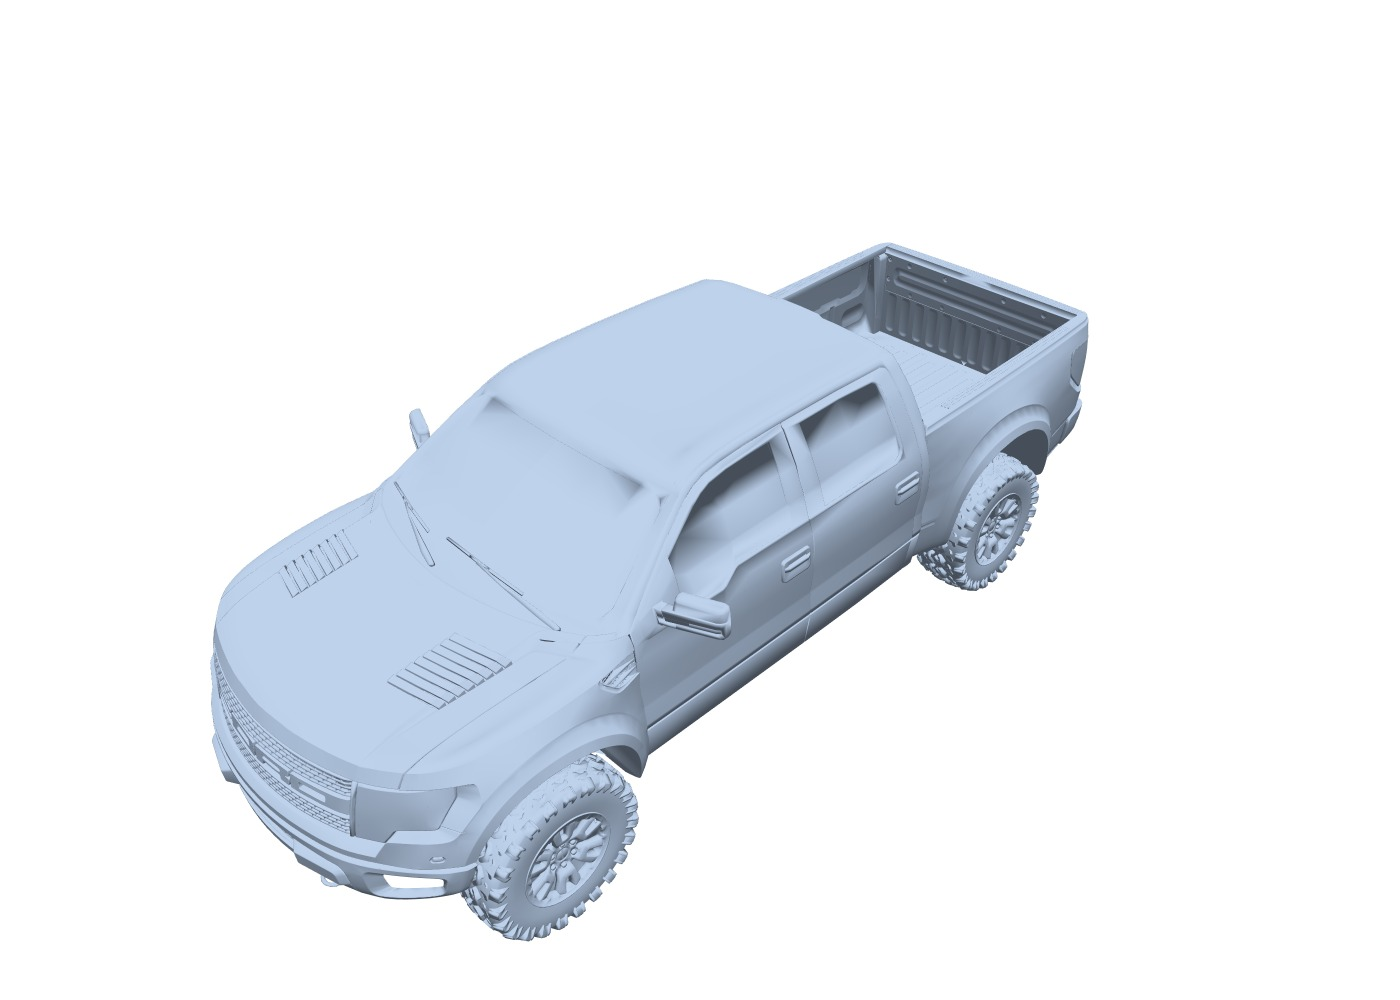

In [ ]:
import pymeshlab

# Load vehicle 3D mesh
ms = pymeshlab.MeshSet()
ms.load_new_mesh(target_1["model"])
t_mesh = ms.current_mesh()

# Extract vertex positions and face connectivity
v_matrix = np.array(t_mesh.vertex_matrix())
f_matrix = np.array(t_mesh.face_matrix())

# Create 3D mesh visualization
fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=v_matrix[:, 0],
        y=v_matrix[:, 1],
        z=v_matrix[:, 2],
        i=f_matrix[:, 0],
        j=f_matrix[:, 1],
        k=f_matrix[:, 2],
        color="lightsteelblue",
        flatshading=False,
        lighting=dict(ambient=0.4, diffuse=0.9, specular=0.3, roughness=0.5),
        lightposition=dict(x=1000, y=500, z=1000),
    )
)

# Configure 3D plot layout
fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
    ),
    height=500,
    margin=dict(l=0, r=0, b=0, t=0),
)

show(fig)

## Radar Scene Simulation

Ray tracing with density = 0.1 rays/λ² (balance accuracy vs. speed for large targets). Output: `[1 channel × 512 pulses × ~160 samples]`. System noise added for realistic SNR.

In [ ]:
# Import radar simulator and timing module
from radarsimpy.simulator import sim_radar
import time

# Start timing
tic = time.time()

# Simulate radar returns from vehicle and ground plane
# density=0.1: Ray tracing density (rays per wavelength²)
# debug=False: Suppress detailed progress output
data = sim_radar(radar, targets, density=0.1)

# Extract baseband I/Q signals and add system noise
baseband = data["baseband"] + data["noise"]  # Complex samples (I + jQ)

# End timing
toc = time.time()

# Display execution time
print("Exec time:", toc - tic, "s")

Exec time: 3.2529423236846924 s


## Radar Signal Processing

### Range FFT Processing

Apply Chebyshev window (60 dB sidelobes) and FFT across fast-time to convert beat frequencies to range bins. Range resolution: ΔR = c/(2B) = 1.5 m.

In [ ]:
# Import signal processing modules
from scipy import signal
import radarsimpy.processing as proc

# Create Chebyshev window for range FFT (60 dB sidelobe suppression)
range_window = signal.windows.chebwin(radar.sample_prop["samples_per_pulse"], at=60)

# Perform range FFT to convert beat frequencies to range
# Input: baseband [channels, pulses, samples]
# Output: range_profile [channels, pulses, range_bins]
range_profile = proc.range_fft(baseband, range_window)

### Doppler FFT Processing

Apply Chebyshev window (60 dB) and FFT across slow-time (pulses) to extract velocity. Velocity resolution: Δv = λ/(2×N×PRP) ≈ 0.038 m/s. Negative Doppler → approaching; zero Doppler → stationary (ground clutter); positive Doppler → receding. For −10 m/s vehicle: Doppler ≈ −5.1 kHz.

In [ ]:
# Create Chebyshev window for Doppler FFT (60 dB sidelobe suppression)
doppler_window = signal.windows.chebwin(
    radar.radar_prop["transmitter"].waveform_prop["pulses"], at=60
)

# Perform Doppler FFT to extract velocity information
# Input: range_profile [channels, pulses, range_bins]
# Output: range_doppler [channels, Doppler_bins, range_bins]
range_doppler = proc.doppler_fft(range_profile, doppler_window)

### Range-Doppler Map

Expected: vehicle peak at (~150 m, −10 m/s), strong zero-Doppler ground clutter across all ranges, possible multipath secondary peaks from ground bounce.

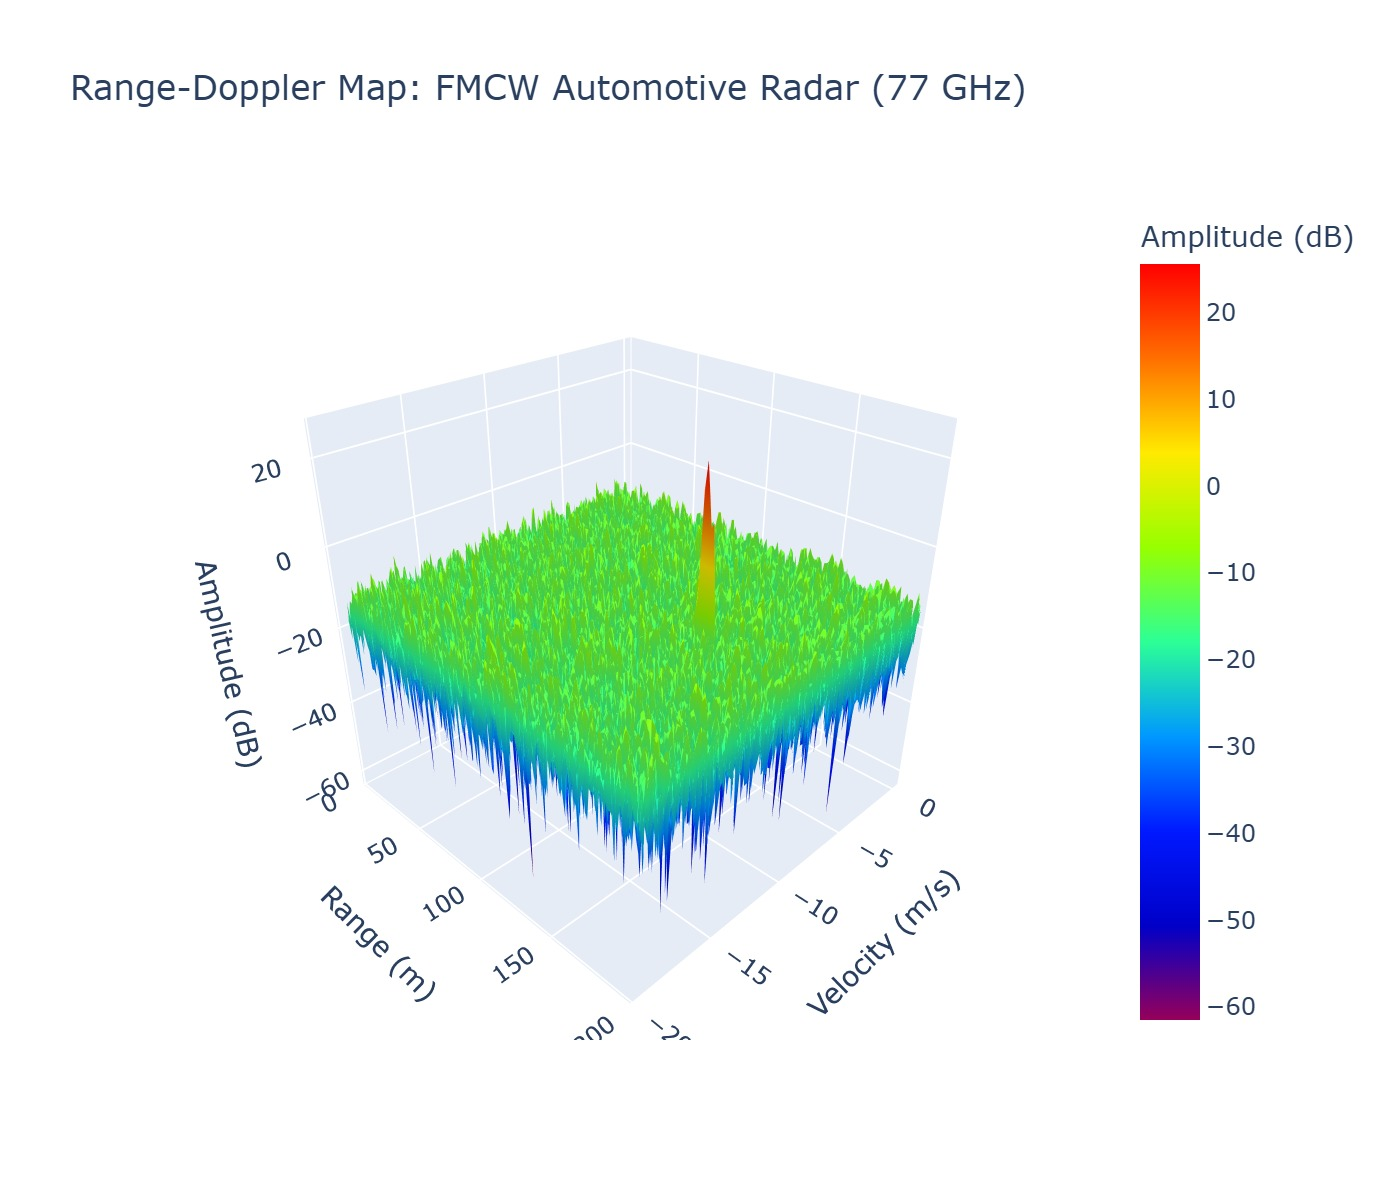

In [ ]:
# Calculate maximum unambiguous range
max_range = (
    3e8
    * radar.radar_prop["receiver"].bb_prop["fs"]
    * radar.radar_prop["transmitter"].waveform_prop["pulse_length"]
    / radar.radar_prop["transmitter"].waveform_prop["bandwidth"]
    / 2
)

# Calculate unambiguous velocity
unambiguous_speed = (
    3e8
    / radar.radar_prop["transmitter"].waveform_prop["prp"][0]
    / 77e9
    / 2
)

# Create range axis
range_axis = np.linspace(
    0, max_range, radar.sample_prop["samples_per_pulse"], endpoint=False
)

# Create Doppler/velocity axis (negative velocities = closing targets)
doppler_axis = np.linspace(
    -unambiguous_speed,
    0,
    radar.radar_prop["transmitter"].waveform_prop["pulses"],
    endpoint=False,
)

# Create 3D surface plot
fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=range_axis,
        y=doppler_axis,
        z=20 * np.log10(np.abs(range_doppler[0, :, :])),
        colorscale="Rainbow",
        colorbar=dict(title="Amplitude (dB)"),
    )
)

fig.update_layout(
    title="Range-Doppler Map: FMCW Automotive Radar (77 GHz)",
    height=600,
    scene=dict(
        xaxis=dict(title="Range (m)", range=[0, 200]),
        yaxis=dict(title="Velocity (m/s)"),
        zaxis=dict(title="Amplitude (dB)"),
        aspectmode="cube",
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1.2)),
    ),
)

show(fig)

## Summary

- FMCW radar simultaneously measures range (via beat frequency $f_{beat} = 2BR/(cT_c)$) and velocity (via Doppler across chirps)
- 77 GHz automotive radar with 100 MHz BW provides 1.5 m range resolution; 512 chirps yield 0.038 m/s velocity resolution
- Ford Raptor at 150 m approaching at −10 m/s appears as a strong peak at (150 m, −10 m/s) in the Range-Doppler map
- Ground plane (ε_r = 3.2 + 0.1j) creates zero-Doppler clutter and multipath effects
- Two-dimensional FFT processing (Range FFT → Doppler FFT) forms the basis for automotive ADAS applications: ACC, AEB, blind spot detection

### Things to Try

| Experiment | How |
|------------|-----|
| Increase range resolution | Use 200 MHz or 500 MHz BW; observe ΔR = c/(2B) improvement |
| Vary chirp count | Try 128, 256, 1024; see velocity resolution Δv = λ/(2N×PRP) change |
| Multiple vehicles | Add targets at different ranges/velocities; test multi-target detection |
| Change vehicle speed | Test 0 m/s, +15 m/s, −30 m/s; observe Doppler shift and aliasing |
| Range scenarios | Close (10 m parking), medium (50 m urban), long (200 m highway) |
| Window functions | Compare Hamming, Hanning, Blackman; trade sidelobe vs. resolution |
| Remove ground | Simulate without ground plane; see direct returns only |
| MIMO configuration | Add multiple TX/RX for angular resolution |
